In [44]:
#Reference
#https://github.com/fnusatvik07/langgraph-agent/blob/main/01_agents.ipynb

In [45]:
!pip install langchain langchain-groq langgraph python-dotenv ipython --quiet

**No-1 Set-Up**

In [46]:
#Load environment variables from .env
from dotenv import load_dotenv
load_dotenv("/content/.env.txt")

True

In [47]:
print(os.getenv("GROQ_API_KEY"))

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


In [91]:
# For graph visualization
from IPython.display import Image, display
from langchain_core.runnables.graph_mermaid import draw_mermaid_png

# Initialize Groq model
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "groq:llama-3.3-70b-versatile",
    temperature=0
)

print("LLM ready")

# Show LangGraph
def show(graph):
  "Render a compiled LangGraph as an inline mermaid PNG (ASCII fallback if offline)."
  try:
        display(Image(graph.get_graph().draw_mermaid_png()))
  except Exception:
        print(graph.get_graph().draw_ascii())

# Render Mermaid diagram text
def render_mermaid(mermaid_text):
  "Render any mermaid diagram string as an inline PNG."
  display(Image(draw_mermaid_png(mermaid_text)))

# Test LLM
response = llm.invoke("What is LangGraph?")
print(response.content)

LLM ready
LangGraph is an open-source, large language model developed by the LangGraph team. It's designed to process and generate human-like language, similar to other models like LLaMA or BERT. 

LangGraph uses a combination of natural language processing (NLP) and machine learning algorithms to analyze and understand the context, syntax, and semantics of language. This allows it to generate coherent and context-specific text based on a given prompt or input.

Some key features of LangGraph include:

1. **Large-scale training data**: LangGraph is trained on a massive dataset of text from various sources, including books, articles, and websites.
2. **Advanced architecture**: The model uses a transformer-based architecture, which is well-suited for NLP tasks.
3. **Open-source**: LangGraph is open-source, allowing developers and researchers to access, modify, and extend the model.
4. **Customizable**: LangGraph can be fine-tuned for specific tasks or domains, making it a versatile tool 

**mermaid diagrams:**

In [106]:
render_mermaid('''
graph TD  #Mermaid syntax
    S([START]) --> L["llm node<br/>(Reason)"]
    L -->|asked for a tool| T["tool node<br/>(Act)"]
    T -->|observe result| L
    L -->|no tool: final answer| E([END])
''')

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph. Status code: 400.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

you cannot use graph TD, graph LR, graph RL, and graph BT together in the same Mermaid graph. Only **one graph <direction> is allowed per graph.**

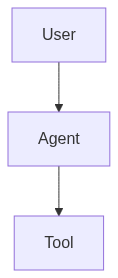

In [56]:
render_mermaid("""
graph TD
    A[User] --> B[Agent]
    B --> C[Tool]
""")


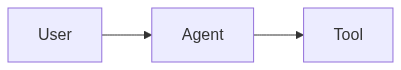

In [54]:
render_mermaid("""
graph LR
    A[User] --> B[Agent]
    B --> C[Tool]
""")

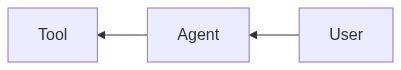

In [55]:
render_mermaid("""
graph RL
    A[User] --> B[Agent]
    B --> C[Tool]
""")


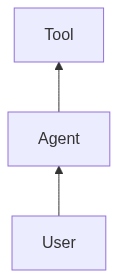

In [53]:
render_mermaid("""
graph BT
    A[User] --> B[Agent]
    B --> C[Tool]
""")

**No-2 The tools, and how the LLM "asks" for one**

In [52]:
from langchain.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers a and b."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers a and b."""
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """Divide a by b."""
    return a / b

tools = [add, multiply, divide]
print("tool name:", add.name)
print("tool desc:", add.description)
print("tool args:", add.args)

tool name: add
tool desc: Add two numbers a and b.
tool args: {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


**Binding tools with LLM**

In [59]:
llm_with_tools = llm.bind_tools(tools)

from langchain.messages import HumanMessage
ai_msg = llm_with_tools.invoke([HumanMessage("What is 3 plus 4?")])

print("content    :", repr(ai_msg.content), "  <- empty: the model didn't answer, it wants a tool")
print("tool_calls :", ai_msg.tool_calls)

content    : ''   <- empty: the model didn't answer, it wants a tool
tool_calls : [{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'hmdd2s60q', 'type': 'tool_call'}]


In [60]:
repr(ai_msg.content) # Python-friendly(shows quotes)

"''"

In [ ]:
#Let's prove the reducer appends:

In [61]:
from langgraph.graph.message import add_messages
from langchain.messages import HumanMessage, AIMessage

conversation = [HumanMessage("hi")]

print(conversation, "\n")

conversation = add_messages(
    conversation,
    [AIMessage("hello there!")]
)

print(conversation, "\n")

for msg in conversation:
    print(msg.type, ":", msg.content)

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={})] 

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='b7611636-3d0c-4e06-b2f7-93432b4d8b77'), AIMessage(content='hello there!', additional_kwargs={}, response_metadata={}, id='1579ebef-c1c5-4940-b665-77d598224b6c', tool_calls=[], invalid_tool_calls=[])] 

human : hi
ai : hello there!


In [62]:
#prepends system message
from langchain.messages import SystemMessage

messages = [
    SystemMessage("You are a helpful assistant."),
    HumanMessage("hi")
]

print(messages)

[SystemMessage(content='You are a helpful assistant.', additional_kwargs={}, response_metadata={}), HumanMessage(content='hi', additional_kwargs={}, response_metadata={})]


**Node 1 LLM node(Reason)**

In [ ]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage

SYSTEM = "You are a helpful assistant that does arithmetic on a set of inputs."

def llm_node(state: MessagesState):
    """Reason: let the model think and (maybe) request a tool."""
    response = llm_with_tools.invoke([SystemMessage(SYSTEM)] + state["messages"])
    return {"messages": [response]}   # appended to the conversation by add_messages

**Node 2 TOOL node(Act)**

In [68]:
from typing import TypedDict,Annotated

In [70]:
from langchain_core.messages import AnyMessage

In [71]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [72]:
from langchain.messages import ToolMessage

In [73]:
ai_last_message=ai_msg

In [77]:
def tool_node(state):

    # Step 1: Make a dictionary like a phone book
    # { "search_tool": <search function>, "calculator": <calc function> }
    tool_phonebook = {tool.name: tool for tool in tools} #tools=[tool1,tool2]

    # Step 2: Get the last message — this is what the AI just said
    # The AI said: "Please call these tools for me"
    ai_last_message = state["messages"][-1]

    # Step 3: Create an empty list to collect all tool results
    all_results = []

    # Step 4: The AI may have asked for MORE than one tool at once
    # So we loop through each tool request one by one(tool req from LLM)
    for one_tool_request in ai_last_message.tool_calls:

        # Step 5: Find the actual tool using the name the AI gave
        tool_name   = one_tool_request["name"]       # e.g. "search_tool"
        tool_to_run = tool_phonebook[tool_name]       # get the actual function

        # Step 6: Run the tool with the arguments the AI provided
        tool_args   = one_tool_request["args"]        # e.g. {"query": "weather today"}
        tool_result = tool_to_run.invoke(tool_args)   # actually execute it

        # Step 7: Wrap the result in a ToolMessage
        # This is like putting the food on a plate with a ticket number
        # so the AI knows which order this result belongs to
        result_message = ToolMessage(
            content      = str(tool_result),          # the answer/output
            tool_call_id = one_tool_request["id"],    # the ticket number (links back to the request)
        )

        all_results.append(result_message)

    # Step 8: Return all results — they get added to the conversation history
    return {"messages": all_results}

In [82]:
#print(*dir(ai_last_message), sep="\n")  #unpacking  (consisting tool_calls)

In [83]:
print("type:", ai_last_message.type)
print("content:", ai_last_message.content)
print("tool_calls:", ai_last_message.tool_calls)
print("id:", ai_last_message.id)

type: ai
content: 
tool_calls: [{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'hmdd2s60q', 'type': 'tool_call'}]
id: lc_run--019e7d0e-1908-7eb1-b68c-14513843d025-0


Note: tool_call_id links each result back to the exact request.

**The router - what creates the loop**

In [84]:
from langgraph.graph import END
from typing_extensions import Literal

def should_continue(state: MessagesState) -> Literal["tool_node", "__end__"]:
    """Route to tools if the model asked for them, else finish."""
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    return END

**Wire it all up**

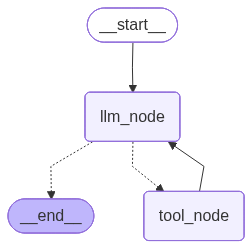

In [85]:
from langgraph.graph import StateGraph, START

builder = StateGraph(MessagesState)          # <- our state is MessagesState
builder.add_node("llm_node", llm_node)
builder.add_node("tool_node", tool_node)

builder.add_edge(START, "llm_node")
builder.add_conditional_edges(               # branch after the LLM node
    "llm_node",
    should_continue,
    ["tool_node", END],                      # the possible destinations
)
builder.add_edge("tool_node", "llm_node")    # <- the agent loop

agent = builder.compile()
show(agent)

**Run it**

In [88]:
result = agent.invoke({"messages": [HumanMessage("What is 7 plus 5?")]})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 7 plus 5?
================================== Ai Message ==================================
Tool Calls:
  add (39p7m1xgx)
 Call ID: 39p7m1xgx
  Args:
    a: 7
    b: 5
================================= Tool Message =================================

12
================================== Ai Message ==================================

The answer is 12.


**You don't have to write the tool node - ToolNode**

In [ ]:
from langgraph.prebuilt import ToolNode

builder2 = StateGraph(MessagesState)
builder2.add_node("llm_node", llm_node)
builder2.add_node("tool_node", ToolNode(tools))      # <- the only change
builder2.add_edge(START, "llm_node")
builder2.add_conditional_edges("llm_node", should_continue, ["tool_node", END])
builder2.add_edge("tool_node", "llm_node")

agent2 = builder2.compile()
result = agent2.invoke({"messages": [HumanMessage("What is (12 divided by 4) plus 10?")]})
print(result["messages"][-1].content)

**schema error**

In [ ]:
response = llm_with_tools.invoke(
    [HumanMessage("What is (12 divided by 4) plus 10?")]
)

print(response.tool_calls)
'''BadRequestError: Error code: 400 - {'error': {'message': 'tool call validation failed: parameters for tool
add did not match schema: errors: [`/a`: expected integer, but got object]', 'type': 'invalid_request_error',
'code': 'tool_use_failed', 'failed_generation': '<function=add>{"a":{"function":"divide","parameters":{"a":12,"b":4}},"b":10}</function>'}}'''

**LangGraph even ships the routing prebuilt too**

The llm_node <-> tool_node loop with a router is so standard that LangChain wraps the entire thing in create_agent. It builds the very same graph we just built by hand (its nodes are named model and tools

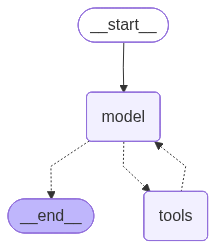

In [100]:
from langchain.agents import create_agent

quick_agent = create_agent(
    model="groq:llama-3.3-70b-versatile",
    tools=tools,
    system_prompt=SYSTEM,
)
show(quick_agent)

In [102]:
out = quick_agent.invoke({"messages": [HumanMessage("What is (12 divided by 4) plus 10?.")]})
print("\nanswer:", out["messages"][-1].content)


answer: The answer is 13.


In [103]:
# same node-and-loop structure, just prebuilt:
print("our agent  :", list(agent.get_graph().nodes))
print("create_agent:", list(quick_agent.get_graph().nodes))


our agent  : ['__start__', 'llm_node', 'tool_node', '__end__']
create_agent: ['__start__', 'model', 'tools', '__end__']
